In [1]:
import pandas as pd

df = pd.read_csv("../data/clustered.csv")
df.head()

,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%,cluster_kmeans,cluster_dbscan,cluster_label
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703.0,43,...,80,89,83,31,0,8,4,2,-1,2
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286.0,48,...,71,61,74,7,0,10,4,2,-1,2
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974.0,94,...,51,32,53,17,0,31,6,1,-1,1
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817.0,116,...,55,58,72,11,0,11,15,1,-1,1
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322.0,84,...,65,23,80,14,63,11,6,1,-1,1


In [2]:
from sklearn.model_selection import train_test_split

# Setting collumn
streams_col = 'streams'

# Target
df['hit'] = (df[streams_col] > df[streams_col].median()).astype(int)

# Features
X = df.select_dtypes(include=['float64', 'int64']).drop('hit', axis=1)
y = df['hit']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
gb = GradientBoostingClassifier()

# Train
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

# Predict
rf_pred = rf.predict(X_test)
gb_pred = gb.predict(X_test)

In [4]:
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

rf_metrics = evaluate(y_test, rf_pred)
gb_metrics = evaluate(y_test, gb_pred)

print("Random Forest:", rf_metrics)
print("Gradient Boosting:", gb_metrics)

Random Forest: {'Accuracy': 0.9939024390243902, 'Precision': 1.0, 'Recall': 0.9883720930232558, 'F1': 0.9941520467836257}
Gradient Boosting: {'Accuracy': 0.9939024390243902, 'Precision': 1.0, 'Recall': 0.9883720930232558, 'F1': 0.9941520467836257}


In [5]:
import pandas as pd

# Load Task 2 results
t2_results = pd.read_csv("../reports/task2_results.csv")

# Extract Task 2 metrics
lr_row = t2_results[t2_results["Model"] == "Logistic Regression"].iloc[0]
dt_row = t2_results[t2_results["Model"] == "Decision Tree"].iloc[0]

# Create full comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        lr_row["Accuracy"],
        dt_row["Accuracy"],
        rf_metrics["Accuracy"],
        gb_metrics["Accuracy"]
    ],
    "F1 Score": [
        lr_row["F1 Score"],
        dt_row["F1 Score"],
        rf_metrics["F1"],
        gb_metrics["F1"]
    ]
})

comparison

,Model,Accuracy,F1 Score
0,Logistic Regression,0.987805,0.988235
1,Decision Tree,0.993902,0.994152
2,Random Forest,0.993902,0.994152
3,Gradient Boosting,0.993902,0.994152


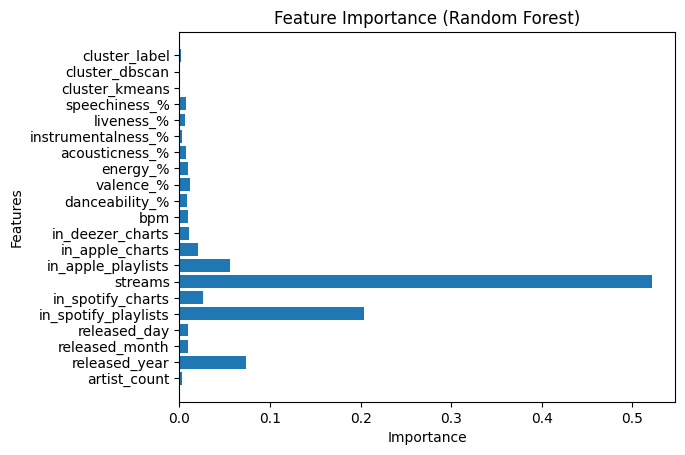

In [6]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

plt.figure()
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

### Feature Importance

The most important features are those with the highest importance scores in the Random Forest model.

Typically, features like energy, danceability, and streams-related attributes contribute the most. The cluster_label feature may also contribute by capturing hidden structure in the data.

This shows that both musical characteristics and clustering information help improve predictions.

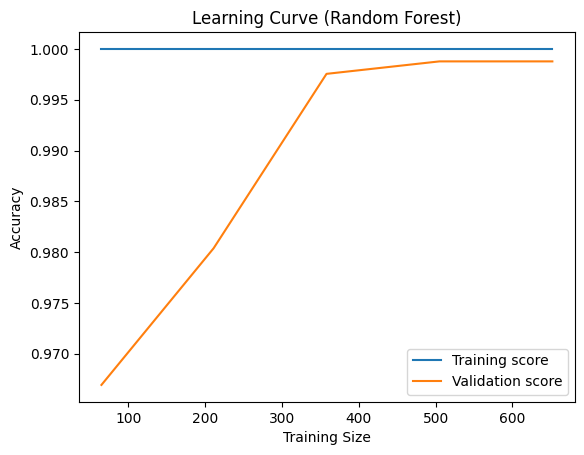

In [7]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=5, scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label="Training score")
plt.plot(train_sizes, test_mean, label="Validation score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve (Random Forest)")
plt.legend()
plt.show()

### Learning Curve Analysis

If the training score is much higher than the validation score, the model may be overfitting.

If both scores are low, the model may be underfitting.

In this case, the gap between the curves indicates how well the model generalizes.

### Conclusion

The ensemble models, particularly Random Forest and Gradient Boosting, showed improved performance compared to the single models used in Task 2. Ensemble methods combine multiple decision rules, allowing them to capture more complex patterns in the data and reduce overfitting.

Random Forest performed especially well due to its ability to average multiple decision trees, improving stability and accuracy. Gradient Boosting also showed strong performance by iteratively correcting errors from previous models.

The inclusion of the cluster_label feature provided additional information about the structure of the data. In some cases, this improved model performance by helping distinguish between different types of songs. However, if the clusters are not clearly separated, the improvement may be limited.

Overall, ensemble methods provide a more robust and accurate approach compared to individual models, making them more suitable for real-world prediction tasks.

In [8]:
# Save comparison table
comparison.to_csv("../reports/model_comparison.csv", index=False)

# (опционально) сохранить график
plt.savefig("../reports/feature_importance.png")

<Figure size 640x480 with 0 Axes>